In [120]:
import pandas as pd
data = pd.read_csv('../Data/preprocessed_data.csv',)

In [121]:
data.isnull().sum()

timestamp                    0
home_country                 0
source_currency              0
dest_currency                0
channel                      0
amount_src                   0
amount_usd                   0
fee                          0
exchange_rate_src_to_dest    0
new_device                   0
ip_address                   0
ip_country                   0
location_mismatch            0
ip_risk_score                0
kyc_tier                     0
account_age_days             0
device_trust_score           0
chargeback_history_count     0
risk_score_internal          0
txn_velocity_1h              0
txn_velocity_24h             0
corridor_risk                0
is_fraud                     0
month                        0
weekday                      0
hour                         0
dtype: int64

### Splitting data Chronologically- Temporal Splitting

In [122]:
data = data.sort_values('timestamp').reset_index(drop = True)

categorical_cols = data.select_dtypes(include = 'object').columns
numerical_cols = data.select_dtypes(include = ['int64', 'float64']).drop(columns = ['is_fraud']).columns

Split_index = int(len(data)*0.8)
train_data  = data.iloc[:Split_index]
test_data = data.iloc[Split_index:]


x_train = train_data.drop('is_fraud', axis = 1)
y_train = train_data['is_fraud']
x_test = test_data.drop('is_fraud',axis = 1)
y_test = test_data['is_fraud']



C:\Users\admin\AppData\Local\Temp\ipykernel_34256\1581499148.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include = 'object').columns


In [123]:
# dropping timestamp column as it is not useful for the model and also to avoid data leakage
x_train= x_train.drop(['timestamp','ip_address'], axis = 1)
x_test  = x_test.drop(['timestamp','ip_address'], axis = 1)


In [124]:
categorical_cols = x_train.select_dtypes(include = 'object').columns
numerical_cols = x_train.select_dtypes(include = ['int64', 'float64']).columns

C:\Users\admin\AppData\Local\Temp\ipykernel_34256\3247640591.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = x_train.select_dtypes(include = 'object').columns


### Standardization and Encoding

In [125]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers =[
    ('cat', OneHotEncoder(drop = 'first', handle_unknown='ignore'), categorical_cols),
    ('num', StandardScaler(), numerical_cols)])

x_train_processed= preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)    

### Train a Base Model

Classification report:/n              precision    recall  f1-score   support

       Legit       0.99      0.95      0.97      1860
       Fraud       0.77      0.94      0.85       308

    accuracy                           0.95      2168
   macro avg       0.88      0.95      0.91      2168
weighted avg       0.96      0.95      0.95      2168

Confusion matrix:/n[[1773   87]
 [  18  290]]
ROC AUC Score: 0.9473921240050273


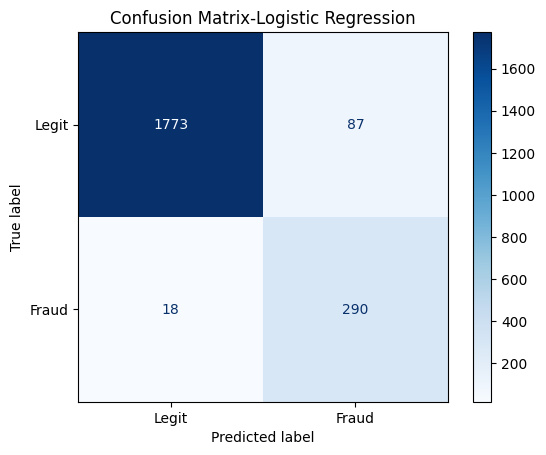

In [141]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train logistic regression model with class_weight = 'balanced' to handle class imbalance
lr_model = LogisticRegression(max_iter = 1000, random_state = 42, class_weight = 'balanced')
lr_model.fit(x_train_processed, y_train)

# predict
y_pred= lr_model.predict(x_test_processed)

# evaluate model
print(f"Classification report:/n{classification_report(y_test, y_pred, target_names = ['Legit', 'Fraud'])}")
print(f"Confusion matrix:/n{confusion_matrix(y_test, y_pred)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred)}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels = ['Legit', 'Fraud'], cmap = 'Blues')
plt.title('Confusion Matrix-Logistic Regression')
plt.show()

Classification report:/n              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99      1860
       Fraud       1.00      0.92      0.96       308

    accuracy                           0.99      2168
   macro avg       0.99      0.96      0.97      2168
weighted avg       0.99      0.99      0.99      2168

Confusion matrix:/n[[1859    1]
 [  25  283]]
ROC AUC Score: 0.9727517106549365


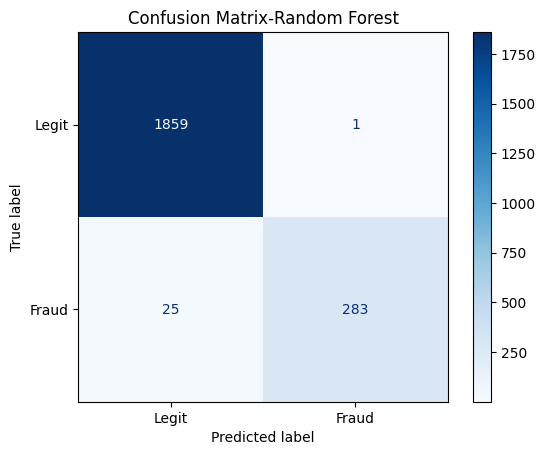

In [139]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(
    n_estimators = 100, random_state = 42, class_weight = 'balanced', max_depth=10 ,n_jobs = -1
)
rf_model.fit(x_train_processed, y_train)
y_pred_ref = rf_model.predict(x_test_processed)
y_proba_rf = rf_model.predict_proba(x_test_processed)[:, 1]


print(f"Classification report:/n{classification_report(y_test, y_pred_ref, target_names = ['Legit', 'Fraud'])}")
print(f"Confusion matrix:/n{confusion_matrix(y_test, y_pred_ref)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf )}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ref, display_labels = ['Legit', 'Fraud'], cmap = 'Blues')
plt.title('Confusion Matrix-Random Forest')
plt.show()


### Hyperparameter Tuning

In [128]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {  
    'n_estimators': [100, 200, 300],
    'max_depth': [None,10,20,30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1,2,4],
    'max_features':    ['sqrt', 'log2',],
    'class_weight': ['balanced', 'balanced_subsample'],}

rf_search = RandomizedSearchCV(
        estimator = RandomForestClassifier(random_state = 42, n_jobs = -1),
        param_distributions= param_dist,
        n_iter = 25,
        cv= 3,
        scoring='f1',
        random_state = 42,
        verbose = 1,
    )
rf_search.fit(x_train_processed, y_train)

for param, value in rf_search.best_params_.items():
    print(f"{param}: {value}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits
n_estimators: 100
min_samples_split: 2
min_samples_leaf: 2
max_features: log2
max_depth: 30
class_weight: balanced_subsample


Classification report:/n              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99      1860
       Fraud       0.99      0.92      0.95       308

    accuracy                           0.99      2168
   macro avg       0.99      0.96      0.97      2168
weighted avg       0.99      0.99      0.99      2168

Confusion matrix:/n[[1858    2]
 [  25  283]]
ROC AUC Score: 0.9760071917329982


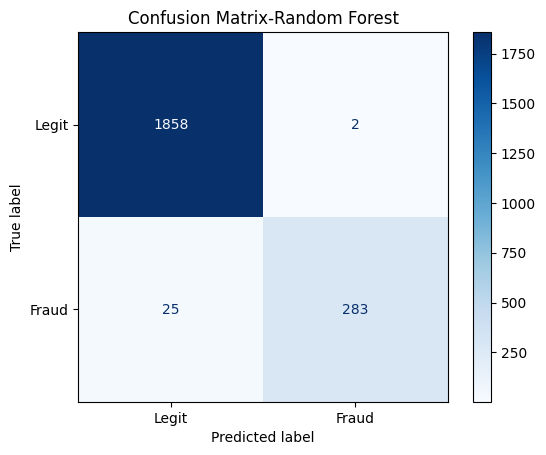

In [135]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(
n_estimators= 100,
min_samples_split= 2,
min_samples_leaf=2,
max_features= 'log2',
max_depth= 30,
class_weight= 'balanced_subsample',
)
rf_model.fit(x_train_processed, y_train)
y_pred_ref = rf_model.predict(x_test_processed)
y_proba_rf = rf_model.predict_proba(x_test_processed)[:, 1]


print(f"Classification report:/n{classification_report(y_test, y_pred_ref, target_names = ['Legit', 'Fraud'])}")
print(f"Confusion matrix:/n{confusion_matrix(y_test, y_pred_ref)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf)}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ref, display_labels = ['Legit', 'Fraud'], cmap = 'Blues')
plt.title('Confusion Matrix-Random Forest')
plt.show()

In [142]:
import joblib

joblib.dump(rf_model, '../models/random_forest_model.pkl')
joblib.dump(preprocessor, '../models/preprocessor.pkl')

['../models/preprocessor.pkl']

### Feature importance

In [ ]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({'Feature': feature_names,'Importance': rf_model.feature_importances_})

importance.sort_values(by='Importance',ascending=False).head(15)

,Feature,Importance
32,num__txn_velocity_24h,0.172280
31,num__txn_velocity_1h,0.149237
26,num__ip_risk_score,0.120180
30,num__risk_score_internal,0.115493
27,num__account_age_days,0.091921
28,num__device_trust_score,0.051648
22,num__amount_src,0.051388
24,num__fee,0.046376
23,num__amount_usd,0.041402
19,cat__kyc_tier_low,0.023659


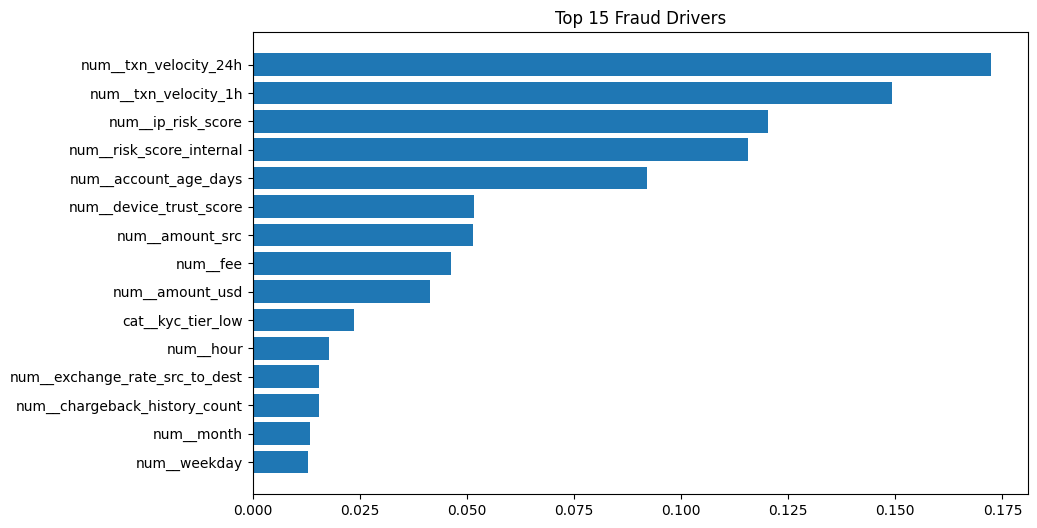

In [ ]:
importance_sorted = importance.sort_values(by='Importance',ascending=False)

top15 = importance_sorted.head(15)

plt.figure(figsize=(10,6))
plt.barh(top15['Feature'], top15['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 15 Fraud Drivers')
plt.show()

The Feature importance analysis above  revealed that transaction velocity within 24 hours and 1 hour were the strongest fraud indicators, followed by IP risk score, internal risk score, account age, and device trust score. This suggests that behavioural and device-based features were more predictive than transaction amount alone.